# Rolling Window IC 비교 실험

## 실험 목적
  - Rolling window 크기(120 / 150 / 180일)에 따른 IC 변화 측정
  - Expanding window(249일) 추가 비교  ← 추가
  - Ablation 4그룹: OHLCV / +Exog / +News_DS / +Exog+News_DS  → "4그룹"
  - 커뮤니티 관련 피처 완전 제외

## 데이터
- 실제 KIS 1분봉 parquet (`artifacts/data/{ticker}/bars_1m_*.parquet`)
- ECOS 외생변수
- Naver 뉴스 기반 Dual-Source

## label
- `label_5m_ret`: 5분 후 수익률 (cross-sectional rank 기준 IC 측정)

---
## 0. 경로 설정 및 라이브러리

In [12]:
import warnings
warnings.filterwarnings('ignore')

import sys
import json
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
from scipy import stats
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── AI 루트 자동 탐지 (노트북 위치 기준) ──────────────────────────────

NB_DIR   = Path().resolve()

AI_ROOT  = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / 'CLAUDE.md').exists()), NB_DIR)
DATA_DIR = AI_ROOT / 'artifacts' / 'data'

sys.path.insert(0, str(AI_ROOT))

print(f'AI_ROOT  : {AI_ROOT}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')

AI_ROOT  : C:\Users\ygjun\OneDrive\바탕 화면\종설_실험\AI
DATA_DIR : C:\Users\ygjun\OneDrive\바탕 화면\종설_실험\AI\artifacts\data
DATA_DIR exists: True


---
## 1. 유니버스 및 실험 설정

In [13]:
import yaml

# ── 유니버스 (sector_config.yaml 기준 30) ──────────────────────
sector_cfg_path = AI_ROOT / 'new' / 'config' / 'sector_config.yaml'
if sector_cfg_path.exists():
    with open(sector_cfg_path, encoding='utf-8') as f:
        sector_cfg = yaml.safe_load(f)
    UNIVERSE = [
    str(t).zfill(6)
    for t in sector_cfg.get('ticker_to_sector', {}).keys()
    ]
    
    print(f'유니버스 로드 완료: {len(UNIVERSE)}종목')
else:
    # fallback: artifacts/data 폴더에 있는 종목 전부
    UNIVERSE = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
    print(f'sector_config 없음 → data 폴더 기준: {len(UNIVERSE)}종목')

print('종목:', UNIVERSE)

# ── 실험 파라미터 ─────────────────────────────────────────────────────
WINDOWS   = [120, 150, 180, 249]   # rolling window (거래일 기준)
LABEL_COL = 'label_5m_ret'    # IC 측정 대상 label
N_FOLDS   = 5                 # walk-forward 분할 수
SEED      = 42

# ── Ablation 그룹 정의 ────────────────────────────────────────────────
#   community 관련 피처는 완전 제외
GROUPS = {
    'OHLCV':              None,
    'OHLCV+Exog':         None,
    'OHLCV+News_DS':      None,
    'OHLCV+Exog+News_DS': None,
}

print('\n실험 설정:')
print(f'  Rolling windows : {WINDOWS}일 (거래일 기준 day-based fold)')
print(f'  Walk-forward    : {N_FOLDS}폴드')
print(f'  Label           : {LABEL_COL}')
print(f'  IC 측정         : cross-sectional (매 ts별 spearman → 평균)')
print(f'  Ablation 그룹   : {list(GROUPS.keys())}')

유니버스 로드 완료: 30종목
종목: ['005930', '000660', '042700', '403870', '058470', '329180', '042660', '010140', '009540', '267250', '006400', '051910', '373220', '096770', '247540', '012450', '047810', '079550', '298040', '272210', '105560', '055550', '086790', '024110', '000810', '005380', '000270', '012330', '011210', '086280']

실험 설정:
  Rolling windows : [120, 150, 180, 249]일 (거래일 기준 day-based fold)
  Walk-forward    : 5폴드
  Label           : label_5m_ret
  IC 측정         : cross-sectional (매 ts별 spearman → 평균)
  Ablation 그룹   : ['OHLCV', 'OHLCV+Exog', 'OHLCV+News_DS', 'OHLCV+Exog+News_DS']


---
## 2. Parquet 로드

In [14]:
def load_bars(ticker: str) -> pd.DataFrame:
    """ticker의 전체 parquet 파일 합쳐서 반환."""
    ticker_dir = DATA_DIR / ticker
    files = sorted(ticker_dir.glob('bars_1m_*.parquet'))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    # timestamp 컬럼 정규화
    ts_col = next((c for c in df.columns if 'time' in c.lower() or 'ts' in c.lower()), None)
    if ts_col and ts_col != 'ts':
        df = df.rename(columns={ts_col: 'ts'})
    if 'ts' in df.columns:
        df['ts'] = pd.to_datetime(df['ts'])
        df = df.sort_values('ts').reset_index(drop=True)
    df['ticker'] = ticker
    return df

# 전체 로드
raw_frames = {}
for tk in UNIVERSE:
    df = load_bars(tk)
    if not df.empty:
        raw_frames[tk] = df
        print(f'  {tk}: {len(df):,}행  ({df["ts"].min().date()} ~ {df["ts"].max().date()})')
    else:
        print(f'  {tk}: 파일 없음 → 스킵')

print(f'\n로드 완료: {len(raw_frames)}/{len(UNIVERSE)} 종목')

  005930: 94,317행  (2025-05-12 ~ 2026-05-18)
  000660: 94,689행  (2025-05-12 ~ 2026-05-18)
  042700: 94,656행  (2025-05-12 ~ 2026-05-18)
  403870: 94,545행  (2025-05-12 ~ 2026-05-18)
  058470: 94,708행  (2025-05-12 ~ 2026-05-18)
  329180: 94,694행  (2025-05-12 ~ 2026-05-18)
  042660: 94,689행  (2025-05-12 ~ 2026-05-18)
  010140: 94,692행  (2025-05-12 ~ 2026-05-18)
  009540: 94,699행  (2025-05-12 ~ 2026-05-18)
  267250: 94,680행  (2025-05-12 ~ 2026-05-18)
  006400: 94,685행  (2025-05-12 ~ 2026-05-18)
  051910: 94,689행  (2025-05-12 ~ 2026-05-18)
  373220: 94,695행  (2025-05-12 ~ 2026-05-18)
  096770: 94,686행  (2025-05-12 ~ 2026-05-18)
  247540: 94,705행  (2025-05-12 ~ 2026-05-18)
  012450: 94,681행  (2025-05-12 ~ 2026-05-18)
  047810: 94,690행  (2025-05-12 ~ 2026-05-18)
  079550: 94,656행  (2025-05-12 ~ 2026-05-18)
  298040: 94,680행  (2025-05-12 ~ 2026-05-18)
  272210: 94,659행  (2025-05-12 ~ 2026-05-18)
  105560: 94,695행  (2025-05-12 ~ 2026-05-18)
  055550: 94,699행  (2025-05-12 ~ 2026-05-18)
  086790: 

---
## 3. 피처 엔지니어링

In [15]:
def compute_ohlcv_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    OHLCV 파생 피처 (커뮤니티 없음).
    dataset_builder._compute_rolling_features 수식 기준.
    """
    c = df['close'].astype(float)
    v = df['volume'].astype(float)
    h = df['high'].astype(float)
    lo = df['low'].astype(float)

    # ── 기존 4개 ──────────────────────────────────────────────────────
    roll30 = c.rolling(30)
    df['feat_1m_close_robust_z'] = (c - roll30.median()) / (roll30.quantile(0.75) - roll30.quantile(0.25) + 1e-9)
    df['feat_5m_ret']            = c.pct_change(5)
    df['feat_30m_vol']           = v.rolling(30).std() / (v.rolling(30).mean() + 1e-9)
    df['feat_60m_trend']         = c.rolling(60).apply(lambda x: np.polyfit(np.arange(len(x)), x, 1)[0] / (x.mean() + 1e-9) if len(x) == 60 else np.nan, raw=True)

    # ── 추가 OHLCV 파생 ───────────────────────────────────────────────
    df['feat_volume_ratio']      = v / (v.rolling(20).mean() + 1e-9)
    df['feat_price_range']       = (h - lo) / (c + 1e-9)
    df['feat_10m_ret']           = c.pct_change(10)
    # VWAP 이탈도
    typical = (h + lo + c) / 3
    vwap    = (typical * v).rolling(30).sum() / (v.rolling(30).sum() + 1e-9)
    df['feat_vwap_dev']          = (c - vwap) / (vwap + 1e-9)

    return df


def compute_exog_features(df: pd.DataFrame, exog: pd.DataFrame) -> pd.DataFrame:
    if exog.empty:
        for col in ['feat_interest_rate', 'feat_usd_krw', 'feat_us_vix',
                     'feat_us_sp500_change', 'feat_us_nasdaq_change', 'feat_us_soxx_change',
                     'feat_foreign_net_buy', 'feat_institutional_net_buy']:
            df[col] = np.nan
        return df
    df['_date']   = df['ts'].dt.date.astype(str)
    df['_ticker'] = df['ticker']
    exog['_date']   = exog['date'].astype(str)
    exog['_ticker'] = exog['ticker'].astype(str).str.zfill(6)
    merge_cols = ['interest_rate', 'usd_krw', 'us_sp500_change', 'us_nasdaq_change',
                  'us_vix', 'us_soxx_change', 'foreign_net_buy', 'institutional_net_buy']
    df = df.merge(exog[['_ticker', '_date'] + merge_cols], on=['_ticker', '_date'], how='left')
    rename = {col: f'feat_{col}' for col in merge_cols}
    df = df.rename(columns=rename)
    df = df.drop(columns=['_date', '_ticker'], errors='ignore')
    return df


def compute_news_ds_features(df: pd.DataFrame, news_daily: pd.DataFrame) -> pd.DataFrame:
    """news_score는 일별 단일 값 → 일별 3일 rolling mean으로 momentum 계산 후 1분봉에 broadcast.
    """
    if news_daily.empty:
        df['feat_news_score'] = 0.0
        df['feat_news_momentum'] = 0.0
        return df

    nd = news_daily.copy()
    nd['_ticker'] = nd['ticker'].astype(str).str.zfill(6)
    nd['_date']   = nd['date'].astype(str)
    nd = nd.sort_values(['_ticker', '_date'])
    # 일별 3일 rolling mean (현재 일 포함, PIT-safe)
    nd['news_momentum_daily'] = (
        nd.groupby('_ticker')['news_score']
          .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )

    df = df.copy()
    df['_date']   = df['ts'].dt.date.astype(str)
    df['_ticker'] = df['ticker']
    df = df.merge(
        nd[['_ticker', '_date', 'news_score', 'news_momentum_daily']],
        on=['_ticker', '_date'], how='left',
    )
    df['feat_news_score']    = df['news_score'].fillna(0.0)
    df['feat_news_momentum'] = df['news_momentum_daily'].fillna(0.0)
    df = df.drop(columns=['_date', '_ticker', 'news_score', 'news_momentum_daily'],
                 errors='ignore')
    return df


def make_label(df: pd.DataFrame, horizon: int = 5) -> pd.DataFrame:
    """5분 후 수익률 label (PIT-safe: shift(-horizon))."""
    df[LABEL_COL] = df['close'].astype(float).pct_change(horizon).shift(-horizon)
    return df


print('피처 함수 정의 완료')

피처 함수 정의 완료


---
## 4. 외생변수 및 뉴스 데이터 로드

In [16]:
import json
from datetime import datetime, time
from zoneinfo import ZoneInfo

_KST = ZoneInfo('Asia/Seoul')


def _is_exog_pit_safe(snapshot_ts_str, batch_date_str) -> bool | None:
    """exog artifact가 batch_date 당일 09:00 KST(시장 개장) 이전 snapshot인지 검증.

    None: 메타데이터 부족 → 보수적으로 None 반환 (호출측에서 정책 결정).
    """
    if not snapshot_ts_str or not batch_date_str:
        return None
    try:
        snap = datetime.fromisoformat(str(snapshot_ts_str))
        if snap.tzinfo is None:
            snap = snap.replace(tzinfo=_KST)
        bd_clean = str(batch_date_str).replace('-', '')
        bd_date = datetime.strptime(bd_clean, '%Y%m%d').date()
        market_open = datetime.combine(bd_date, time(9, 0), tzinfo=_KST)
        return snap <= market_open
    except Exception:
        return None


# 외생변수 (PIT-Safety: snapshot_ts ≤ 시장 개장 09:00 KST)
exog_path = AI_ROOT / 'artifacts' / 'exogenous'
if exog_path.exists():
    records = []
    pit_violations = []
    pit_unknown = []
    for f in sorted(exog_path.glob('*.json')):
        with open(f, encoding='utf-8') as fp:
            data = json.load(fp)
        date = data.get('batch_date', '')
        snap = data.get('snapshot_ts')
        pit_ok = _is_exog_pit_safe(snap, date)
        if pit_ok is False:
            pit_violations.append((date, snap))
            continue  # PIT 위반 → 해당 일자 외생변수 제외
        if pit_ok is None:
            pit_unknown.append(date)
            # 메타 부족: 보수적으로 사용 허용하되 카운트만 보고
        feat = data.get('features', {})
        base = {
            'date':              date,
            'interest_rate':     feat.get('interest_rate', None),
            'usd_krw':           feat.get('usd_krw', None),
            'us_sp500_change':   feat.get('us_sp500_change', None),
            'us_nasdaq_change':  feat.get('us_nasdaq_change', None),
            'us_vix':            feat.get('us_vix', None),
            'us_soxx_change':    feat.get('us_soxx_change', None),
        }
        for ticker, inv in data.get('per_ticker', {}).items():
            row = base.copy()
            row['ticker']                = str(ticker).zfill(6)
            row['foreign_net_buy']       = inv.get('foreign_net_buy', None)
            row['institutional_net_buy'] = inv.get('institutional_net_buy', None)
            records.append(row)
    exog_df = pd.DataFrame(records)
    print(f'외생변수 로드: {len(exog_df)}행  컬럼={list(exog_df.columns)}')
    if pit_violations:
        print(f'  ⚠ PIT 위반 {len(pit_violations)}건 제외 (예: {pit_violations[:3]})')
    if pit_unknown:
        print(f'  ※ snapshot_ts 메타 누락 {len(pit_unknown)}건 (보수적으로 사용)')
else:
    exog_df = pd.DataFrame()
    print('외생변수 파일 없음')

# 뉴스 DS (커뮤니티 완전 제외 — news_score_t만 사용)
# news 산출물은 18:00 KST 이후 batch라 t일 09:00 시장에는 t-1일 score를 사용해야 PIT-safe.
news_path = AI_ROOT / 'artifacts' / 'dual_source'
if news_path.exists():
    records = []
    for f in sorted(news_path.glob('*.json')):
        with open(f, encoding='utf-8') as fp:
            data = json.load(fp)
        date = data.get('batch_date', '')
        for s in data.get('scores', []):
            records.append({
                'date':       date,
                'ticker':     str(s['ticker']).zfill(6),
                'news_score': s.get('news_score_t', 0.0),
            })
    news_df = pd.DataFrame(records)
    # PIT-safe lag: t일에 사용하는 score는 t-1일 batch
    if not news_df.empty:
        news_df['date'] = pd.to_datetime(news_df['date']).dt.date
        news_df = news_df.sort_values(['ticker', 'date'])
        # 일자를 하루 미루어 t-1 batch가 t일에 적용되도록 정렬
        news_df['date'] = (pd.to_datetime(news_df['date']) + pd.Timedelta(days=1)).dt.date.astype(str)
    print(f'뉴스 DS 로드: {len(news_df)}행  컬럼={list(news_df.columns)}  (t-1 lag 적용)')
else:
    news_df = pd.DataFrame()
    print('뉴스 DS 파일 없음')

외생변수 로드: 7500행  컬럼=['date', 'interest_rate', 'usd_krw', 'us_sp500_change', 'us_nasdaq_change', 'us_vix', 'us_soxx_change', 'ticker', 'foreign_net_buy', 'institutional_net_buy']
뉴스 DS 로드: 7500행  컬럼=['date', 'ticker', 'news_score']  (t-1 lag 적용)


---
## 5. 전체 피처 DataFrame 구축

In [17]:
all_frames = []

for tk, df in raw_frames.items():
    df = df.copy()
    df = compute_ohlcv_features(df)
    df = compute_exog_features(df, exog_df)
    df = compute_news_ds_features(df, news_df)
    df = make_label(df)
    all_frames.append(df)

FULL_DF = pd.concat(all_frames, ignore_index=True)
FULL_DF = FULL_DF.dropna(subset=[LABEL_COL])

print(f'전체 DataFrame: {FULL_DF.shape}')
print(f'기간: {FULL_DF["ts"].min().date()} ~ {FULL_DF["ts"].max().date()}')

# ── 피처 그룹 확정 ────────────────────────────────────────────────────
OHLCV_FEATS   = [c for c in FULL_DF.columns if c.startswith('feat_') and
                 not any(x in c for x in ['interest', 'usd', 'us_', 'foreign', 'institutional', 'news'])]
EXOG_FEATS    = [c for c in FULL_DF.columns if c.startswith('feat_') and
                 any(x in c for x in ['interest', 'usd', 'us_', 'foreign', 'institutional'])]
NEWS_DS_FEATS = [c for c in FULL_DF.columns if c.startswith('feat_news')]

GROUPS = {
    'OHLCV':                 OHLCV_FEATS,
    'OHLCV+Exog':            OHLCV_FEATS + EXOG_FEATS,
    'OHLCV+News_DS':         OHLCV_FEATS + NEWS_DS_FEATS,
    'OHLCV+Exog+News_DS':    OHLCV_FEATS + EXOG_FEATS + NEWS_DS_FEATS,
}

print('\n피처 그룹:')
for g, feats in GROUPS.items():
    print(f'  {g:<22}: {len(feats)}개')

전체 DataFrame: (2838255, 32)
기간: 2025-05-12 ~ 2026-05-18

피처 그룹:
  OHLCV                 : 8개
  OHLCV+Exog            : 16개
  OHLCV+News_DS         : 10개
  OHLCV+Exog+News_DS    : 18개


---
## 6. IC 측정 유틸리티

In [18]:
def rank_ic(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """Pooled Spearman rank IC (flat). cross-sectional 용도가 아님."""
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    if mask.sum() < 10:
        return np.nan
    return float(stats.spearmanr(y_pred[mask], y_true[mask]).statistic)


def cross_sectional_ic(eval_df: pd.DataFrame, pred_col: str = '_pred',
                        label_col: str = None, min_per_ts: int = 5
                        ) -> tuple[float, list]:
    """매 timestamp별 spearman(pred, label) 계산 후 평균 (벡터화).

    수학적 동등성:
        spearman(x, y) = pearson(rank(x), rank(y))
                       = Σ(dp·dl) / √(Σdp² · Σdl²)
        여기서 dp = rank(x) - mean(rank(x)), dl = rank(y) - mean(rank(y))

    pandas.rank()는 기본적으로 method='average'를 사용 → scipy.stats.spearmanr 기본
    tie 처리와 일치. 따라서 for-loop 버전과 수치적으로 동일 (부동소수점 마지막 자리 차이만).

    NaN 처리: 시작에 dropna로 NaN 행 제거 (실제 파이프라인엔 NaN 없지만 방어적).
    """
    if label_col is None:
        label_col = LABEL_COL

    df = eval_df[['ts', pred_col, label_col]].dropna()
    if df.empty:
        return float('nan'), []

    # 그룹별 rank (default method='average', scipy와 일치)
    df = df.copy()
    df['rp'] = df.groupby('ts')[pred_col].rank()
    df['rl'] = df.groupby('ts')[label_col].rank()

    # 그룹 평균 빼기 (mean-center)
    grp = df.groupby('ts')
    df['dp'] = df['rp'] - grp['rp'].transform('mean')
    df['dl'] = df['rl'] - grp['rl'].transform('mean')

    df['dp_dl'] = df['dp'] * df['dl']
    df['dp2']   = df['dp'] * df['dp']
    df['dl2']   = df['dl'] * df['dl']

    agg = df.groupby('ts').agg(
        cov=('dp_dl', 'sum'),
        var_p=('dp2', 'sum'),
        var_l=('dl2', 'sum'),
        n=(pred_col, 'size'),
    )
    # 그룹 크기 필터 (원본 if len(g) >= 5와 동일)
    agg = agg[agg['n'] >= min_per_ts]
    if agg.empty:
        return float('nan'), []

    # constant rank (분모 0) 그룹 제외 — scipy도 NaN 반환하는 경우
    denom = np.sqrt(agg['var_p'] * agg['var_l'])
    valid = denom > 1e-12
    if not valid.any():
        return float('nan'), []

    ic_per_ts = (agg.loc[valid, 'cov'] / denom[valid]).values
    return float(np.mean(ic_per_ts)), ic_per_ts.tolist()


def walk_forward_ic(
    df: pd.DataFrame,
    feature_cols: list,
    window_days: int,
    n_folds: int = 5,
    seed: int = 42,
) -> dict:
    """Walk-forward cross-sectional IC 측정.

    - fold / window는 거래일(day) 단위로 분할 (종목 수에 무관).
    - IC는 매 timestamp별 spearman(pred, label)을 계산한 뒤 평균
      (cross-sectional IC, pooled 아님).
    """
    df = df.sort_values('ts').reset_index(drop=True)
    # 거래일 인덱스 (timestamp의 날짜만)
    date_series = df['ts'].dt.date
    unique_days = sorted(date_series.unique())
    n_days = len(unique_days)
    day_to_idx = {d: i for i, d in enumerate(unique_days)}

    fold_size_days = n_days // (n_folds + 1)
    if fold_size_days < 1:
        return {'mean_ic': np.nan, 'std_ic': np.nan, 'ir': np.nan,
                'ic_list': [], 'n_valid': 0,
                'fold_size_days': 0, 'n_days': n_days}

    valid_feats = [f for f in feature_cols if f in df.columns]
    if not valid_feats:
        return {'mean_ic': np.nan, 'std_ic': np.nan, 'ir': np.nan,
                'ic_list': [], 'n_valid': 0,
                'fold_size_days': fold_size_days, 'n_days': n_days}

    lgb_params = dict(
        objective='regression',
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        verbose=-1,
    )

    ic_list = []
    fold_meta = []
    day_idx_array = date_series.map(day_to_idx).values  # bar→day_idx

    for fold in range(n_folds):
        test_day_start = (fold + 1) * fold_size_days
        test_day_end   = min(test_day_start + fold_size_days, n_days)
        train_day_start = max(0, test_day_start - window_days)
        train_day_end   = test_day_start

        if train_day_end - train_day_start < 1 or test_day_end - test_day_start < 1:
            continue

        train_mask = (day_idx_array >= train_day_start) & (day_idx_array < train_day_end)
        test_mask  = (day_idx_array >= test_day_start)  & (day_idx_array < test_day_end)

        train_df = df.loc[train_mask]
        test_df  = df.loc[test_mask]

        if train_df.empty or test_df.empty:
            continue

        # LightGBM은 NaN native handling → fillna 제거
        X_train = train_df[valid_feats].replace([np.inf, -np.inf], np.nan)
        y_train = train_df[LABEL_COL]
        X_test  = test_df[valid_feats].replace([np.inf, -np.inf], np.nan)

        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        eval_df = test_df[['ts', LABEL_COL]].copy()
        eval_df['_pred'] = y_pred
        fold_ic, per_ts_ic = cross_sectional_ic(eval_df)
        if not np.isnan(fold_ic):
            ic_list.append(fold_ic)
            fold_meta.append({
                'fold': fold,
                'train_days': train_day_end - train_day_start,
                'test_days':  test_day_end  - test_day_start,
                'train_rows': int(train_mask.sum()),
                'test_rows':  int(test_mask.sum()),
                'n_per_ts_ic': len(per_ts_ic),
            })

    ic_arr = np.array([x for x in ic_list if not np.isnan(x)])
    return {
        'mean_ic': float(np.mean(ic_arr)) if len(ic_arr) else np.nan,
        'std_ic':  float(np.std(ic_arr))  if len(ic_arr) else np.nan,
        'ir':      float(np.mean(ic_arr) / (np.std(ic_arr) + 1e-9)) if len(ic_arr) else np.nan,
        'ic_list': ic_list,
        'n_valid': len(ic_arr),
        'fold_size_days': fold_size_days,
        'n_days':         n_days,
        'fold_meta':      fold_meta,
    }


print('IC 유틸리티 정의 완료 (cross-sectional 벡터화 + day-based walk-forward)')

IC 유틸리티 정의 완료 (cross-sectional 벡터화 + day-based walk-forward)


---
## 7. 메인 실험: Window × Ablation 그리드

In [19]:
results = {}  # (window, group) → dict

for window in WINDOWS:
    for group_name, feats in GROUPS.items():
        key = (window, group_name)
        print(f'\n[실험] window={window}일  group={group_name}  피처수={len(feats)}')
        res = walk_forward_ic(FULL_DF, feats, window_days=window, n_folds=N_FOLDS, seed=SEED)
        results[key] = res
        print(f'  → mean IC={res["mean_ic"]:+.4f}  std={res["std_ic"]:.4f}  IR={res["ir"]:+.3f}  (n={res["n_valid"]})')

print('\n\n=== 실험 완료 ===')


[실험] window=120일  group=OHLCV  피처수=8
  → mean IC=+0.1528  std=0.0298  IR=+5.120  (n=5)

[실험] window=120일  group=OHLCV+Exog  피처수=16
  → mean IC=+0.1482  std=0.0280  IR=+5.293  (n=5)

[실험] window=120일  group=OHLCV+News_DS  피처수=10
  → mean IC=+0.1495  std=0.0283  IR=+5.276  (n=5)

[실험] window=120일  group=OHLCV+Exog+News_DS  피처수=18
  → mean IC=+0.1473  std=0.0282  IR=+5.223  (n=5)

[실험] window=150일  group=OHLCV  피처수=8
  → mean IC=+0.1532  std=0.0298  IR=+5.136  (n=5)

[실험] window=150일  group=OHLCV+Exog  피처수=16
  → mean IC=+0.1487  std=0.0278  IR=+5.352  (n=5)

[실험] window=150일  group=OHLCV+News_DS  피처수=10
  → mean IC=+0.1500  std=0.0281  IR=+5.335  (n=5)

[실험] window=150일  group=OHLCV+Exog+News_DS  피처수=18
  → mean IC=+0.1469  std=0.0275  IR=+5.343  (n=5)

[실험] window=180일  group=OHLCV  피처수=8
  → mean IC=+0.1540  std=0.0290  IR=+5.313  (n=5)

[실험] window=180일  group=OHLCV+Exog  피처수=16
  → mean IC=+0.1490  std=0.0275  IR=+5.423  (n=5)

[실험] window=180일  group=OHLCV+News_DS  피처수=10
  → mean 

---
## 8. 결과 테이블

In [20]:
rows = []
for (window, group), res in results.items():
    rows.append({
        'Window(일)':  window,
        'Ablation':    group,
        '피처 수':     len(GROUPS[group]),
        'Mean IC':     round(res['mean_ic'], 4),
        'Std IC':      round(res['std_ic'],  4),
        'IC-IR':       round(res['ir'],      3),
        'Valid Folds': res['n_valid'],
    })

result_df = pd.DataFrame(rows)
result_df = result_df.sort_values(['Window(일)', 'Ablation']).reset_index(drop=True)

# IC 기준선 표시
IC_THRESHOLD = 0.02
def highlight_ic(val):
    if isinstance(val, float):
        if abs(val) >= IC_THRESHOLD:
            return 'background-color: #d4edda; font-weight: bold'
        elif val < 0:
            return 'background-color: #f8d7da'
    return ''

display(result_df.style.applymap(highlight_ic, subset=['Mean IC']))

print(f'\n※ |IC| >= {IC_THRESHOLD} (risk_config 기준) → 초록 / IC < 0 → 빨강')

,Window(일),Ablation,피처 수,Mean IC,Std IC,IC-IR,Valid Folds
0,120,OHLCV,8,0.152800,0.029800,5.120000,5
1,120,OHLCV+Exog,16,0.148200,0.028000,5.293000,5
2,120,OHLCV+Exog+News_DS,18,0.147300,0.028200,5.223000,5
3,120,OHLCV+News_DS,10,0.149500,0.028300,5.276000,5
4,150,OHLCV,8,0.153200,0.029800,5.136000,5
5,150,OHLCV+Exog,16,0.148700,0.027800,5.352000,5
6,150,OHLCV+Exog+News_DS,18,0.146900,0.027500,5.343000,5
7,150,OHLCV+News_DS,10,0.150000,0.028100,5.335000,5
8,180,OHLCV,8,0.154000,0.029000,5.313000,5
9,180,OHLCV+Exog,16,0.149000,0.027500,5.423000,5



※ |IC| >= 0.02 (risk_config 기준) → 초록 / IC < 0 → 빨강


---
## 9. 시각화 — Fold별 IC 추이 (최적 window)

최적 window: 180일  (전체 그룹 mean_ic 평균 기준)
  window별 그룹 평균 IC:
    w=120: +0.1494
    w=150: +0.1497
    w=180: +0.1503
    w=249: +0.1503


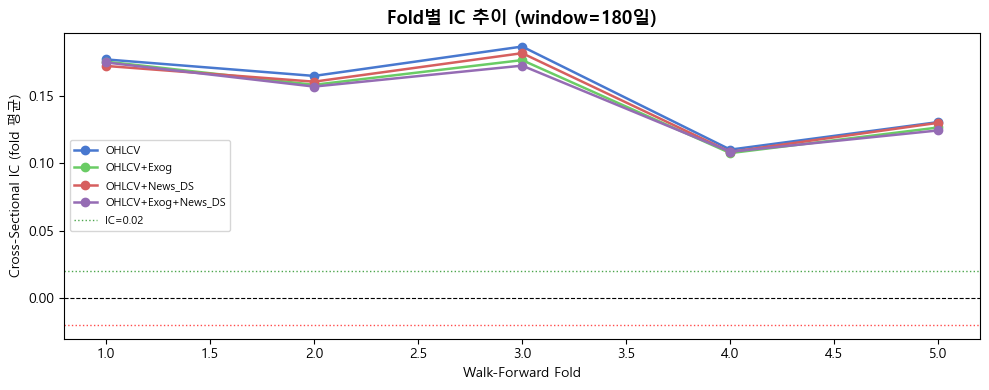

In [27]:
# 최적 window: 전체 그룹 mean_ic 평균이 가장 높은 window
def _window_score(w):
    vals = [results[(w, g)]['mean_ic'] for g in GROUPS.keys()]
    vals = [v for v in vals if not np.isnan(v)]
    return float(np.mean(vals)) if vals else float('-inf')

best_window = max(WINDOWS, key=_window_score)
print(f'최적 window: {best_window}일  (전체 그룹 mean_ic 평균 기준)')
print('  window별 그룹 평균 IC:')
for w in WINDOWS:
    print(f'    w={w}: {_window_score(w):+.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
for group_name, color in colors.items():
    if (best_window, group_name) not in results:
        continue
    ic_list = results[(best_window, group_name)]['ic_list']
    ax.plot(range(1, len(ic_list)+1), ic_list, marker='o', label=group_name,
            color=color, linewidth=1.8, markersize=6)

ax.axhline(0,  color='black', linewidth=0.8, linestyle='--')
ax.axhline( IC_THRESHOLD, color='green', linewidth=1, linestyle=':', alpha=0.7, label=f'IC={IC_THRESHOLD}')
ax.axhline(-IC_THRESHOLD, color='red',   linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel('Walk-Forward Fold')
ax.set_ylabel('Cross-Sectional IC (fold 평균)')
ax.set_title(f'Fold별 IC 추이 (window={best_window}일)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(AI_ROOT / 'artifacts' / f'ic_fold_trend_w{best_window}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 피처 중요도 (최적 window + 전체 그룹)

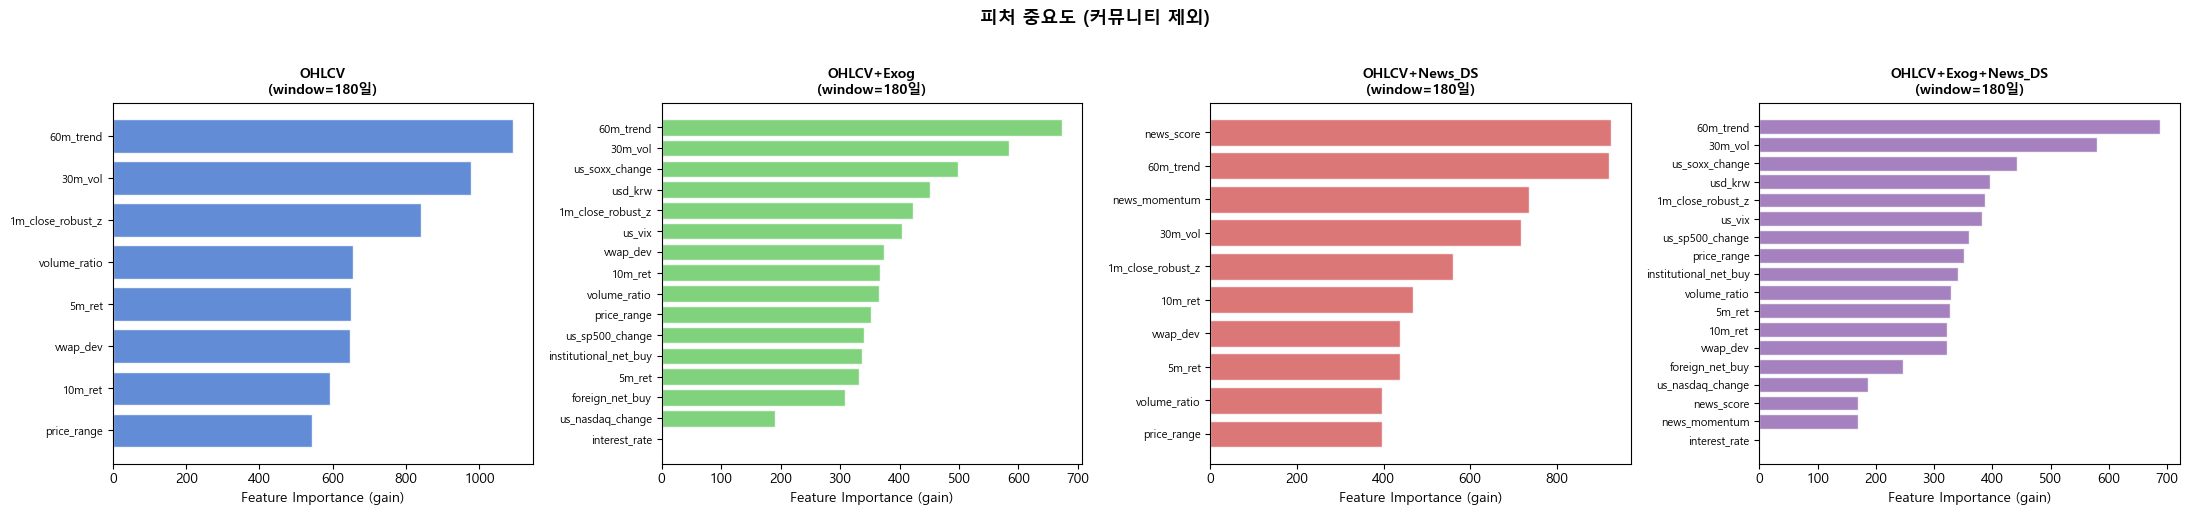

In [28]:
def get_feature_importance(df, feature_cols, window_days, seed=42):
    """day-based window: 마지막 window_days 거래일만 사용."""
    df = df.sort_values('ts')
    unique_days = sorted(df['ts'].dt.date.unique())
    if len(unique_days) > window_days:
        cutoff = unique_days[-window_days]
        df = df[df['ts'].dt.date >= cutoff]
    valid_feats = [f for f in feature_cols if f in df.columns]
    X = df[valid_feats].replace([np.inf, -np.inf], np.nan)  # LGBM NaN native
    y = df[LABEL_COL]
    model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                               num_leaves=31, random_state=seed, verbose=-1)
    model.fit(X, y)
    return dict(zip(valid_feats, model.feature_importances_))


n_groups = len(GROUPS)
fig, axes = plt.subplots(1, n_groups, figsize=(5.5 * n_groups, 5))
if n_groups == 1:
    axes = [axes]

for ax, (group_name, feats) in zip(axes, GROUPS.items()):
    imp = get_feature_importance(FULL_DF, feats, best_window)
    imp_sorted = dict(sorted(imp.items(), key=lambda x: x[1], reverse=True))
    names = [k.replace('feat_', '') for k in imp_sorted.keys()]
    vals  = list(imp_sorted.values())
    ax.barh(names, vals, color=colors[group_name], alpha=0.85, edgecolor='white')
    ax.set_title(f'{group_name}\n(window={best_window}일)', fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (gain)')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('피처 중요도 (커뮤니티 제외)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(AI_ROOT / 'artifacts' / f'feature_importance_w{best_window}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. 결과 저장 및 요약

In [29]:
# JSON 저장
out_dir = AI_ROOT / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)

save_data = {
    'experiment': 'rolling_window_ic_ablation',
    'timestamp':  datetime.now().isoformat(),
    'config': {
        'windows':         WINDOWS,
        'n_folds':         N_FOLDS,
        'label':           LABEL_COL,
        'ic_threshold':    IC_THRESHOLD,
        'community_feats': 'excluded',
        'ic_metric':       'cross_sectional_per_ts_mean',
        'fold_scheme':     'day_based_walk_forward',
    },
    'feature_groups': {g: feats for g, feats in GROUPS.items()},
    'results': {
        f'w{w}_{g}': {
            'mean_ic':        res['mean_ic'],
            'std_ic':         res['std_ic'],
            'ir':             res['ir'],
            'ic_list':        res['ic_list'],
            'n_valid':        res['n_valid'],
            'fold_size_days': res.get('fold_size_days'),
            'n_days':         res.get('n_days'),
            'fold_meta':      res.get('fold_meta', []),
        }
        for (w, g), res in results.items()
    },
    'best_window': best_window,
}

out_path = out_dir / 'rolling_window_ic_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(save_data, f, ensure_ascii=False, indent=2)
print(f'결과 저장: {out_path}')

# ── 최종 요약 출력 ────────────────────────────────────────────────────
print('\n' + '='*70)
print('Rolling Window IC 실험 최종 요약 (cross-sectional, day-based)')
print('='*70)
print(f'  데이터    : 실제 KIS parquet  ({len(raw_frames)}종목)')
print(f'  기간      : {FULL_DF["ts"].min().date()} ~ {FULL_DF["ts"].max().date()}')
print(f'  Label     : {LABEL_COL}')
print(f'  커뮤니티  : 완전 제외')
print(f'  IC 측정   : 매 ts별 spearman(pred, label) 평균')
print()
print(f'{"Window":>8} | {"Ablation":<22} | {"Mean IC":>8} | {"Std IC":>7} | {"IC-IR":>6}')
print('-'*64)
for (w, g), res in sorted(results.items()):
    flag = ' ✓' if abs(res['mean_ic']) >= IC_THRESHOLD else ''
    mean_str = f'{res["mean_ic"]:>+8.4f}' if not np.isnan(res['mean_ic']) else '     NaN'
    std_str  = f'{res["std_ic"]:>7.4f}'   if not np.isnan(res['std_ic'])  else '    NaN'
    ir_str   = f'{res["ir"]:>+6.3f}'      if not np.isnan(res['ir'])      else '   NaN'
    print(f'{w:>8}일 | {g:<22} | {mean_str} | {std_str} | {ir_str}{flag}')
print()
print(f'최적 window: {best_window}일  (전체 그룹 mean_ic 평균 기준)')
print(f'IC 기준선   : |IC| >= {IC_THRESHOLD} (risk_config.yaml ic_significance_threshold)')

결과 저장: C:\Users\ygjun\OneDrive\바탕 화면\종설_실험\AI\artifacts\rolling_window_ic_results.json

Rolling Window IC 실험 최종 요약 (cross-sectional, day-based)
  데이터    : 실제 KIS parquet  (30종목)
  기간      : 2025-05-12 ~ 2026-05-18
  Label     : label_5m_ret
  커뮤니티  : 완전 제외
  IC 측정   : 매 ts별 spearman(pred, label) 평균

  Window | Ablation               |  Mean IC |  Std IC |  IC-IR
----------------------------------------------------------------
     120일 | OHLCV                  |  +0.1528 |  0.0298 | +5.120 ✓
     120일 | OHLCV+Exog             |  +0.1482 |  0.0280 | +5.293 ✓
     120일 | OHLCV+Exog+News_DS     |  +0.1473 |  0.0282 | +5.223 ✓
     120일 | OHLCV+News_DS          |  +0.1495 |  0.0283 | +5.276 ✓
     150일 | OHLCV                  |  +0.1532 |  0.0298 | +5.136 ✓
     150일 | OHLCV+Exog             |  +0.1487 |  0.0278 | +5.352 ✓
     150일 | OHLCV+Exog+News_DS     |  +0.1469 |  0.0275 | +5.343 ✓
     150일 | OHLCV+News_DS          |  +0.1500 |  0.0281 | +5.335 ✓
     180일 | OHLCV                 

---
## 12. Sanity Check — feat_5m_ret 제거 시 IC 변화

label = `label_5m_ret` (5분 후 수익률), 피처 중 `feat_5m_ret` (과거 5분 return)이
인접 시점이라 의심스러움. 이 피처 하나만 빼고 동일 실험을 돌려 IC가 얼마나 떨어지는지 확인.

- 떨어짐이 작음 → 다른 피처들도 정보 기여 (정상)
- 절반 이하로 폭락 → IC 대부분이 단일 피처에서 → 실질 알파 신뢰도 의심

In [32]:
# feat_5m_ret를 제외한 새 GROUPS 정의
SUSPECT_FEATURE = 'feat_5m_ret'

GROUPS_NO5M = {
    name: [f for f in feats if f != SUSPECT_FEATURE]
    for name, feats in GROUPS.items()
}

print(f'Sanity check: {SUSPECT_FEATURE} 제외')
print(f'{"Group":<22} | {"전체":>5} | {"제외 후":>7} | {"피처 변화":<30}')
print('-'*80)
for name in GROUPS:
    orig = GROUPS[name]
    new  = GROUPS_NO5M[name]
    removed = [f for f in orig if f not in new]
    print(f'{name:<22} | {len(orig):>5} | {len(new):>7} | -{removed}')

# 동일 walk_forward_ic 실행 (windows × 4 groups)
results_no5m = {}
print('\n[Sanity check 실험]')
for window in [120]:
    for group_name, feats in GROUPS_NO5M.items():
        key = (window, group_name)
        res = walk_forward_ic(FULL_DF, feats, window_days=window,
                               n_folds=N_FOLDS, seed=SEED)
        results_no5m[key] = res
        print(f'  w={window} {group_name:<22} → mean IC={res["mean_ic"]:+.4f}  '
              f'IR={res["ir"]:+.3f}  (n={res["n_valid"]})')

# 비교 표
print('\n' + '='*80)
print(f'IC 비교: 원본 vs {SUSPECT_FEATURE} 제외')
print('='*80)
print(f'{"Window":>6} | {"Group":<22} | {"원본 IC":>9} | {"제외 IC":>9} | {"Δ":>8} | {"비율":>6}')
print('-'*80)
for w in [120]:
    for g in GROUPS:
        orig_ic = results[(w, g)]['mean_ic']
        new_ic  = results_no5m[(w, g)]['mean_ic']
        delta   = new_ic - orig_ic
        ratio   = (new_ic / orig_ic) if orig_ic != 0 else float('nan')
        print(f'{w:>6}일 | {g:<22} | {orig_ic:>+9.4f} | {new_ic:>+9.4f} | '
              f'{delta:>+8.4f} | {ratio:>5.1%}')

# 판정
print('\n해석 가이드:')
print('  - 제외 후 IC가 원본의 50% 이상 유지 → 다른 피처도 알파 기여 (정상)')
print('  - 제외 후 IC가 50% 미만 (예: 0.15 → <0.075) → feat_5m_ret이 IC 대부분 견인')
print('  - 제외 후 IC가 거의 0 (<0.02) → feat_5m_ret만 알파, 나머지는 노이즈')

Sanity check: feat_5m_ret 제외
Group                  |    전체 |    제외 후 | 피처 변화                         
--------------------------------------------------------------------------------
OHLCV                  |     8 |       7 | -['feat_5m_ret']
OHLCV+Exog             |    16 |      15 | -['feat_5m_ret']
OHLCV+News_DS          |    10 |       9 | -['feat_5m_ret']
OHLCV+Exog+News_DS     |    18 |      17 | -['feat_5m_ret']

[Sanity check 실험]
  w=120 OHLCV                  → mean IC=+0.1342  IR=+4.742  (n=5)
  w=120 OHLCV+Exog             → mean IC=+0.1290  IR=+4.718  (n=5)
  w=120 OHLCV+News_DS          → mean IC=+0.1298  IR=+4.930  (n=5)
  w=120 OHLCV+Exog+News_DS     → mean IC=+0.1288  IR=+4.813  (n=5)

IC 비교: 원본 vs feat_5m_ret 제외
Window | Group                  |     원본 IC |     제외 IC |        Δ |     비율
--------------------------------------------------------------------------------
   120일 | OHLCV                  |   +0.1528 |   +0.1342 |  -0.0186 | 87.8%
   120일 | OHLCV+Exog       